# 29 · Five-model frontier review

This public review summarizes the latest AWS-only diversity/ensemble work after the Qwen3-14B study. It uses **aggregate metrics only**. Raw comments, row-level predictions, exact ensemble weights, adapters, optimizer state, caches, credentials, and full cloud logs remain private.

The retained official Kaggle result remains **0.91808 public / 0.91425 private ROC AUC**. The five-model candidate below is development evidence, not a new leaderboard score.

Loaded public frontier checkpoint: development_candidate_promoted_pending_official_score
Rows: 881 | Policies: 2
PLOTLY_AND_SVG_RENDERED


,System,Policy-macro AUC
0,Qwen2.5 standalone,0.730772
1,Prior 4-model global,0.734595
2,Fixed insertion,0.738231
3,Promoted 5-model global,0.740351


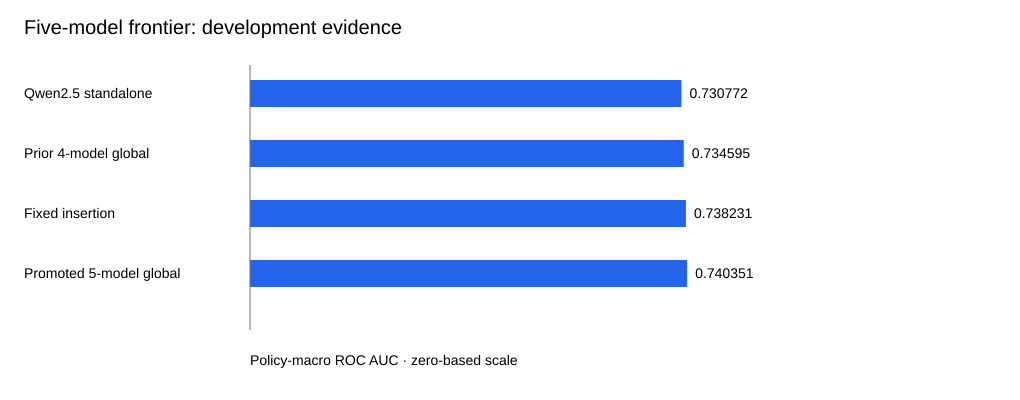

In [1]:
import json
import html
from pathlib import Path
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / "reports/checkpoints/five_model_frontier.json").is_file():
    if ROOT.parent == ROOT:
        raise RuntimeError("Open this notebook within the repository checkout")
    ROOT = ROOT.parent
record = json.loads((ROOT / 'reports/checkpoints/five_model_frontier.json').read_text())
rows = [
    ('Qwen2.5 standalone', record['full_oof']['qwen25_standalone_macro_auc']),
    ('Prior 4-model global', record['global_deployment_validation']['prior_four_model_global_macro_auc']),
    ('Fixed insertion', record['full_oof']['fixed_insertion_macro_auc']),
    ('Promoted 5-model global', record['global_deployment_validation']['promoted_five_model_global_macro_auc']),
]
frame = pd.DataFrame(rows, columns=['System', 'Policy-macro AUC'])
display(frame.round(6))
labels = frame['System'].tolist()
values = frame['Policy-macro AUC'].tolist()
fig = go.Figure(go.Bar(x=values, y=labels, orientation='h',
    text=[f'{value:.6f}' for value in values], textposition='outside',
    marker_color='#2563eb', cliponaxis=False))
fig.update_layout(template='plotly_white', title='Five-model frontier: development evidence',
    height=400, width=1020, margin=dict(l=235, r=85, t=70, b=65),
    xaxis=dict(title='Policy-macro ROC AUC · zero-based scale', range=[0, 1.05]),
    yaxis=dict(autorange='reversed'), showlegend=False)
svg = ['<svg xmlns="http://www.w3.org/2000/svg" width="1020" height="400" viewBox="0 0 1020 400">',
    '<rect width="1020" height="400" fill="white"/>',
    '<text x="24" y="34" font-size="20" font-family="Arial">Five-model frontier: development evidence</text>']
for i, (label, value) in enumerate(zip(labels, values, strict=True)):
    y = 80 + i * 60
    width = 620 * value / 1.05
    svg += [f'<text x="24" y="{y+18}" font-size="14" font-family="Arial">{html.escape(label)}</text>',
            f'<rect x="250" y="{y}" width="{width:.2f}" height="27" fill="#2563eb"/>',
            f'<text x="{258+width:.2f}" y="{y+18}" font-size="14" font-family="Arial">{value:.6f}</text>']
svg += ['<line x1="250" x2="250" y1="65" y2="330" stroke="#64748b"/>',
        '<text x="250" y="365" font-size="14" font-family="Arial">Policy-macro ROC AUC · zero-based scale</text>', '</svg>']
display({'application/vnd.plotly.v1+json': fig.to_plotly_json(),
         'image/svg+xml': ''.join(svg)}, raw=True)
print('Loaded public frontier checkpoint:', record['status'])
print('Rows:', record['development_cohort']['rows'], '| Policies:', record['development_cohort']['policies'])
print('PLOTLY_AND_SVG_RENDERED')

In [2]:
global_result = record['global_deployment_validation']
print(f"Promoted five-model global macro AUC: {global_result['promoted_five_model_global_macro_auc']:.6f}")
print(f"Gain vs prior global deployment: {global_result['gain']:+.6f}")
print(f"Advertising gain: {global_result['per_policy_gain']['advertising']:+.6f}")
print(f"Legal-advice gain: {global_result['per_policy_gain']['legal_advice']:+.6f}")
print(f"Bootstrap probability positive: {global_result['grouped_bootstrap']['probability_positive']:.4f}")
print('Exact deployment weights public:', global_result['exact_weights_public'])
print('Private leaderboard score used for selection:', global_result['private_leaderboard_score_used_for_selection'])
print('Official Kaggle score unchanged: 0.91808 public / 0.91425 private')
print('FOLLOWING_CELL_EXECUTED')

Promoted five-model global macro AUC: 0.740351
Gain vs prior global deployment: +0.005757
Advertising gain: +0.008060
Legal-advice gain: +0.003454
Bootstrap probability positive: 0.9783
Exact deployment weights public: False
Private leaderboard score used for selection: False
Official Kaggle score unchanged: 0.91808 public / 0.91425 private
FOLLOWING_CELL_EXECUTED


## Interpretation

The new backbone is not better in isolation. Its value is complementary ranking behavior. A fixed insertion improved both observed policies and survived grouped-bootstrap uncertainty, while an aggressively optimized LOPO blend and a compact 2/3-model deployment were rejected on stability grounds.

The promoted candidate is therefore a **fixed five-model prior**, with exact deployment weights intentionally kept out of the public repository. This remains a development-promoted candidate; no official score is reported for it. Subsequent matched-control research is summarized in [notebook 31](31_complete_project_review.ipynb).